# 2. Redes Neuronales Recurrentes
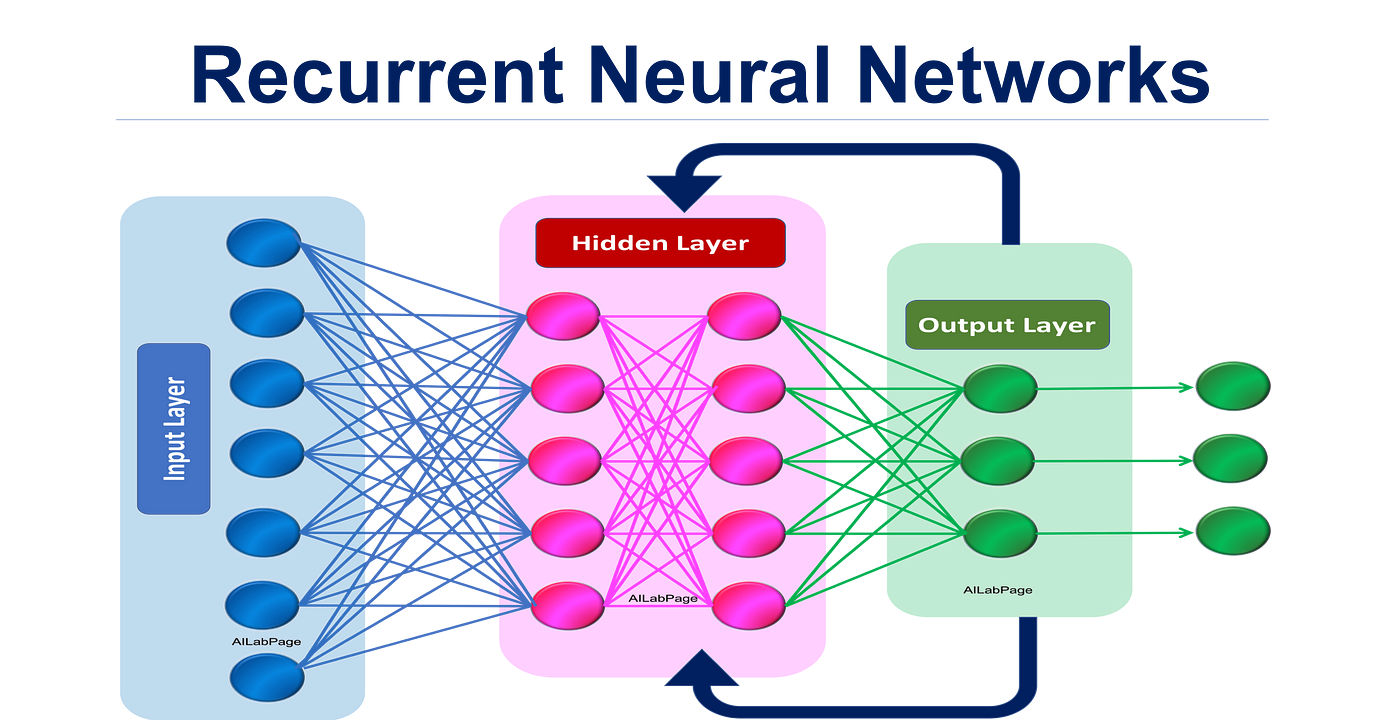

# 1. Chatbot en Español utilizando RNNs

En el siguiente ejemplo crearemos un chatbot en español utilizando Redes Neuronales Recurrentes (RNNs). Para ello, utilizaremos un conjunto de datos de preguntas y respuestas en español. El objetivo es entrenar un modelo que pueda mantener una conversación sencilla con el usuario.


### Ejercicio:
1. Modifica el chatbot para incluir respuestas personalizadas para preguntas frecuentes relacionadas con trámites gubernamentales (por ejemplo, horarios de oficina, requisitos para obtener una licencia, etc.).
2. Entrena el modelo con nuevas frases generadas por ti y evalúa cómo responde a entradas fuera del conjunto de datos original.


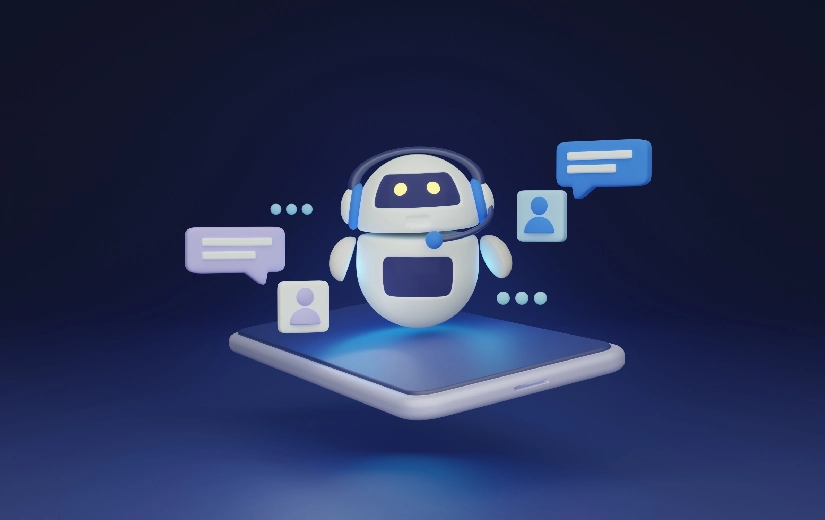

## Importar las librerías necesarias

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import json
import random

## Cargar y preprocesar el conjunto de datos

Para este ejemplo, utilizaremos un conjunto de datos simple que crearemos manualmente. Sin embargo, puedes reemplazarlo con cualquier conjunto de datos de preguntas y respuestas en español que desees.

###  Datos de trámites de Gobierno del Estado

In [2]:
# Fuente: https://asistenciaspf.queretaro.gob.mx/Inscripcion_preguntas_frecuentes.html
# Definir el conjunto de datos de preguntas y respuestas
data = {
    "intents": [
        {"tag": "inscripcion_obligados",
         "patterns": ["¿Quiénes están obligados a inscribirse?", "¿Quién debe inscribirse?", "Obligados a inscribirse"],
         "responses": ["Las personas físicas o morales que por su actividad económica sean causantes de los impuestos contemplados en la Ley de Hacienda del Estado de Querétaro."]},
        {"tag": "inscripcion_cuando",
         "patterns": ["¿Cuándo debo realizar este trámite?", "Plazo para realizar la inscripción", "¿Cuándo inscribirme?"],
         "responses": ["Dentro de los diez días hábiles siguientes a la fecha de inicio de operaciones, mediante la aplicación de la inscripción al padrón vía internet."]},
        {"tag": "inscripcion_como",
         "patterns": ["¿Cómo puedo realizar la inscripción?", "¿Cómo inscribirme?", "Pasos para la inscripción"],
         "responses": [
             "La inscripción se realiza en la página de asistenciaspf.queretaro.gob.mx. El proceso consta de cinco pasos, donde debe registrar y guardar información. Recibirá un aviso de aceptación tras la validación."
         ]},
        {"tag": "inscripcion_requisitos",
         "patterns": ["¿Cuáles son los requisitos para inscribirme?", "Documentos para la inscripción", "Requisitos de inscripción"],
         "responses": [
             "Debe presentar: Aviso de Inscripción al Padrón Estatal firmado, Constancia de Situación Fiscal del SAT, Aviso de Registro Patronal del IMSS en Querétaro, comprobante de domicilio, identificación oficial y otros según sea persona física o moral."
         ]},
        {"tag": "inscripcion_respuesta",
         "patterns": ["¿Cómo sabré si fue aceptado el trámite?", "Confirmación del trámite", "Respuesta de inscripción"],
         "responses": [
             "Recibirá un correo electrónico al finalizar el proceso con la respuesta del estatus del trámite y las claves de usuario y contraseña para declarar en www.recaudanet.gob.mx."
         ]},
        {"tag": "inscripcion_tiempo_respuesta",
         "patterns": ["¿En qué tiempo tendré respuesta?", "Tiempo para respuesta de inscripción", "¿Cuánto tarda la inscripción?"],
         "responses": ["La respuesta tarda entre uno y dos días hábiles, una vez ingresada la solicitud."]},
        {"tag": "impuesto_hospedaje",
         "patterns": ["Requisitos para el impuesto sobre hospedaje", "Documentos hospedaje", "Trámite de hospedaje"],
         "responses": [
             "Debe incluir: Formato de solicitud de cédula, fotografías del establecimiento (fachada, recepción e interiores). Este formato se obtiene al finalizar el paso cuatro del proceso."
         ]}
        # Más preguntas y respuestas se pueden agregar aquí...
    ]
}


In [3]:
# Definir el conjunto de datos de preguntas y respuestas
data = {
    "intents": [
        {"tag": "saludo",
         "patterns": ["Hola", "Buenos días", "Buenas tardes", "¿Qué tal?", "¿Cómo estás?"],
         "responses": ["Hola, ¿en qué puedo ayudarte?", "Saludos, ¿cómo puedo asistirte?", "Hola, estoy aquí para ayudarte."]},
        {"tag": "despedida",
         "patterns": ["Adiós", "Hasta luego", "Nos vemos", "Chao", "Me voy"],
         "responses": ["Hasta luego, que tengas un buen día.", "Adiós, fue un placer ayudarte.", "Nos vemos pronto."]},
        {"tag": "agradecimiento",
         "patterns": ["Gracias", "Muchas gracias", "Te lo agradezco", "Eres muy amable"],
         "responses": ["No hay de qué.", "¡Siempre a tu disposición!", "Es un placer ayudar."]},
        {"tag": "edad",
         "patterns": ["¿Cuántos años tienes?", "¿Cuál es tu edad?", "¿Eres viejo?", "¿Eres joven?"],
         "responses": ["Soy tan viejo como el tiempo.", "Tengo la edad de las ideas.", "Mi edad es infinita."]},
        {"tag": "nombre",
         "patterns": ["¿Cómo te llamas?", "¿Cuál es tu nombre?", "Dime tu nombre"],
         "responses": ["Mi nombre es Chatbot.", "Puedes llamarme Chatbot.", "Soy Chatbot, tu asistente virtual."]}
    ]
}


### Preparar los datos para el entrenamiento

In [4]:
# Extraer patrones y respuestas
patterns = []
tags = []
responses = {}

for intent in data['intents']:
    for pattern in intent['patterns']:
        patterns.append(pattern)
        tags.append(intent['tag'])
    responses[intent['tag']] = intent['responses']

# Tokenización y creación de secuencias
tokenizer = Tokenizer()
tokenizer.fit_on_texts(patterns)
word_index = tokenizer.word_index
total_words = len(word_index) + 1

# Convertir patrones a secuencias
input_sequences = []
for pattern in patterns:
    token_list = tokenizer.texts_to_sequences([pattern])[0]
    input_sequences.append(token_list)

# Obtener la longitud máxima de las secuencias
max_seq_len = max([len(seq) for seq in input_sequences])

# Rellenar las secuencias
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='post'))

# Convertir etiquetas a números
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(tags)
encoded_tags = label_encoder.transform(tags)

# Convertir etiquetas a categorías
y = tf.keras.utils.to_categorical(encoded_tags)

## Construir el modelo

In [5]:
model = Sequential()
model.add(Embedding(total_words, 64, input_length=max_seq_len))
model.add(LSTM(256, return_sequences=True))
model.add(LSTM(128))
model.add(Dense(128, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Entrenar el modelo

In [6]:
history = model.fit(input_sequences, y, epochs=200, verbose=1)
print("Modelo entrenado.")

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.1905 - loss: 1.6096
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4286 - loss: 1.6063
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3810 - loss: 1.6033
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5238 - loss: 1.5995
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5238 - loss: 1.5949
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5238 - loss: 1.5894
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5238 - loss: 1.5826
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4762 - loss: 1.5741
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4762 - loss: 1.5637
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4762 - loss: 1.5507
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4762 - loss: 1.5346
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4762 - lo

## Crear el chatbot

Ahora, crearemos una función para interactuar con el chatbot. Tomará la entrada del usuario, la procesará y generará una respuesta adecuada.

In [7]:
def chatbot_response(text):
    # Preprocesar la entrada del usuario
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_seq_len, padding='post')

    # Predecir la etiqueta
    pred = model.predict(seq, verbose=0)
    tag_index = np.argmax(pred)
    tag = label_encoder.inverse_transform([tag_index])[0]

    # Seleccionar una respuesta aleatoria
    response = random.choice(responses[tag])
    return response

## Interactuar con el chatbot

In [8]:
print("¡Hola! Soy un chatbot. Escribe 'salir' para terminar la conversación.")
while True:
    user_input = input("Tú: ")
    if user_input.lower() == "salir":
        print("Chatbot: ¡Hasta luego!")
        break
    response = chatbot_response(user_input)
    print("Chatbot:", response)

¡Hola! Soy un chatbot. Escribe 'salir' para terminar la conversación.
Tú: salir
Chatbot: ¡Hasta luego!


## Ejercicios
1. **Ampliar el vocabulario**: Añade más intenciones y patrones al conjunto de datos para que el chatbot pueda responder a más tipos de preguntas y mantener conversaciones más complejas.

2. **Implementar procesamiento de lenguaje natural**: Incorpora técnicas de procesamiento de lenguaje natural (PLN) como la lematización o la eliminación de stopwords para mejorar el preprocesamiento y aumentar la precisión del chatbot.

3. **Guardar y cargar el modelo**: Modifica el código para guardar el modelo entrenado en un archivo y cargarlo posteriormente, evitando tener que entrenarlo cada vez que quieras utilizar el chatbot.


# Clasificación de Comentarios de IMDB con Red Neuronales Recurrentes

Este notebook demuestra el proceso de clasificación de comentarios de películas del conjunto de datos de IMDB usando TensorFlow, Keras, y una Red Neuronal Recurrente (RNN).



## Paso 1: Importación de Bibliotecas Necesarias


In [9]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display


## Paso 2: Carga del Conjunto de Datos de IMDB


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


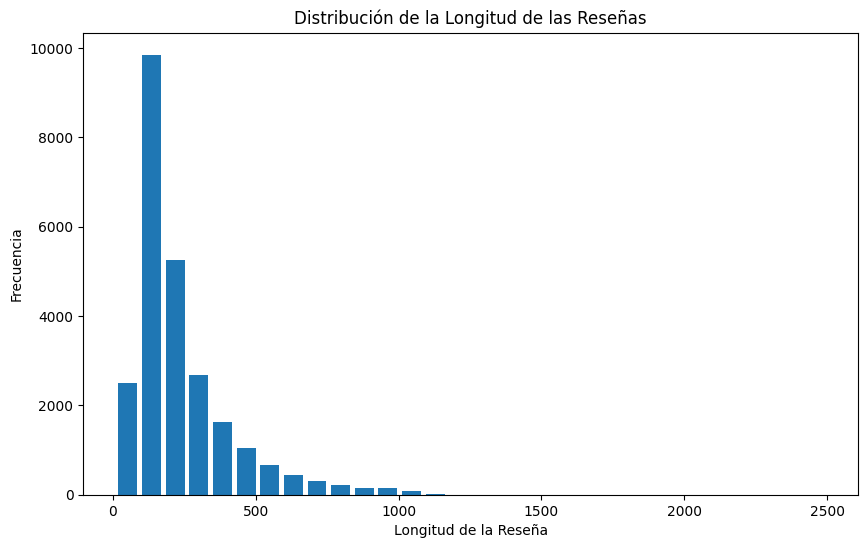

In [10]:

# Load the IMDB dataset
vocabulary_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocabulary_size)

# Visualización de la longitud de las reseñas
lengths = [len(x) for x in x_train]
plt.figure(figsize=(10,6))
plt.hist(lengths, bins=30, rwidth=0.8)
plt.title('Distribución de la Longitud de las Reseñas')
plt.xlabel('Longitud de la Reseña')
plt.ylabel('Frecuencia')
plt.show()


## Paso 3: Visualización de los Datos Iniciales


In [11]:

# Obtener el índice de palabras de IMDB
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def print_review(index=0):
    # Decodificar la reseña seleccionada
    decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in x_train[index]])

    # Imprimir la reseña codificada y decodificada
    print("Etiqueta: ", "positive" if(y_train[index] == 1) else "negative", "\n")
    print("Reseña codificada:", x_train[index])
    print("\nReseña decodificada:\n", decoded_review)

# Crear un control deslizante para seleccionar el ID de la reseña
slider = widgets.IntSlider(value=0, min=0, max=len(x_train)-1, step=1, description='ID de Reseña:')
widgets.interactive(print_review, index=slider)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


interactive(children=(IntSlider(value=0, description='ID de Reseña:', max=24999), Output()), _dom_classes=('wi…


## Paso 4: Preprocesamiento de los Datos


In [12]:
# Preprocess the data
max_length = 500
x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')
print(x_train[0])

[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  144   30 5535   18   51   36   28  224   92   25  104
    4 


## Paso 5: Construcción del Modelo de Clasificación con RNN


In [13]:
# Build the RNN classification model
model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=256, input_length=max_length),
    Bidirectional(LSTM(256, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(128)),
    Dense(1, activation='sigmoid')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


## Paso 6: Entrenamiento del Modelo


In [14]:

# Train the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test), batch_size=128)


Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 415ms/step - accuracy: 0.7463 - loss: 0.5207 - val_accuracy: 0.8330 - val_loss: 0.4408
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 438ms/step - accuracy: 0.8404 - loss: 0.3946 - val_accuracy: 0.8317 - val_loss: 0.4480
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 439ms/step - accuracy: 0.8787 - loss: 0.3237 - val_accuracy: 0.8480 - val_loss: 0.4204
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 439ms/step - accuracy: 0.9126 - loss: 0.2366 - val_accuracy: 0.8641 - val_loss: 0.3588
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 440ms/step - accuracy: 0.9395 - loss: 0.1726 - val_accuracy: 0.8552 - val_loss: 0.3944
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 104s 533ms/step - accuracy: 0.9566 - loss: 0.1285 - val_accuracy: 0.8544 - val_loss: 0.4781
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 441ms/step - accuracy: 0.9557 - loss: 0.1262 - val_accuracy: 0.8341 - val_loss: 0.5358
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 86s 439ms/step - accuracy: 0.9628 - loss: 


## Paso 7: Evaluación del Modelo y Visualización de Resultados


In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 512)       │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801,797 (48.83 MB)

 Trainable params: 4,267,265 (16.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,534,532 (32.56 MB)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8424 - loss: 0.6478
Test Accuracy: 84.24%
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step


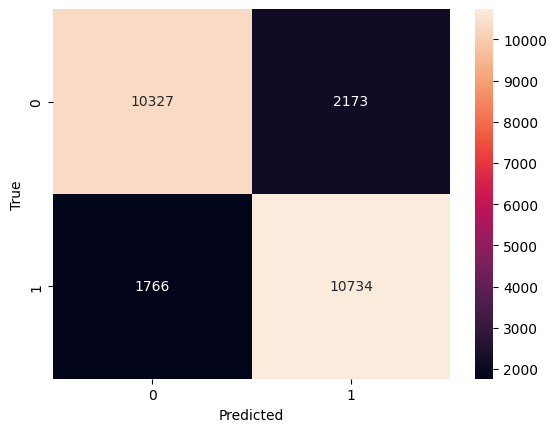

In [16]:

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Predictions
predictions = (model.predict(x_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## 2. Predicción de series temporales con LSTM (Datos de acciones de Google)

**Descripción:**

Utilizaremos datos históricos de las acciones de Google para predecir el precio de cierre utilizando una LSTM.

**Instrucciones:**

1. Importar las librerías necesarias.
2. Cargar los datos desde Yahoo Finance.
3. Preprocesar los datos y crear secuencias.
4. Construir y entrenar el modelo LSTM.
5. Realizar predicciones y visualizar los resultados.

**Ejercicio:**

Intenta cambiar la longitud de las secuencias de entrada y observa cómo afecta al rendimiento del modelo.

/tmp/ipykernel_7608/2593390547.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('NVDA', start='2010-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


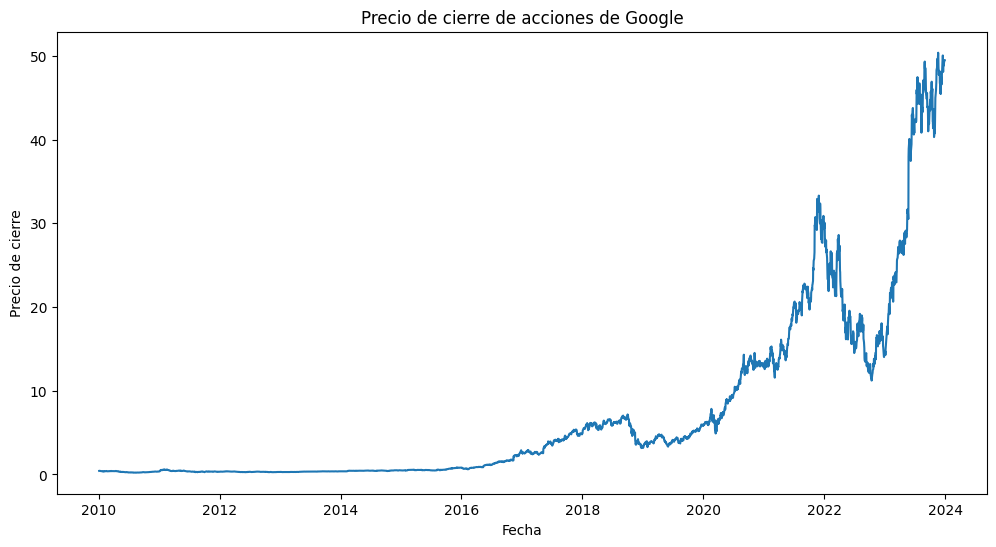

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 1.4843e-04 - val_loss: 0.0019
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 3.0927e-05 - val_loss: 8.5985e-04
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 3.2422e-05 - val_loss: 0.0019
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 2.2577e-05 - val_loss: 8.0124e-04
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 2.6423e-05 - val_loss: 5.9111e-04
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.4167e-05 - val_loss: 0.0016
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 2.2522e-05 - val_loss: 4.0407e-04
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.4919e-05 - val_loss: 4.7281e-04
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 1.5423e-05 - val_loss: 3.7696e-04
Epoch 10/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.3136e-05 - val_loss: 0.0011
Epoch 11/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.

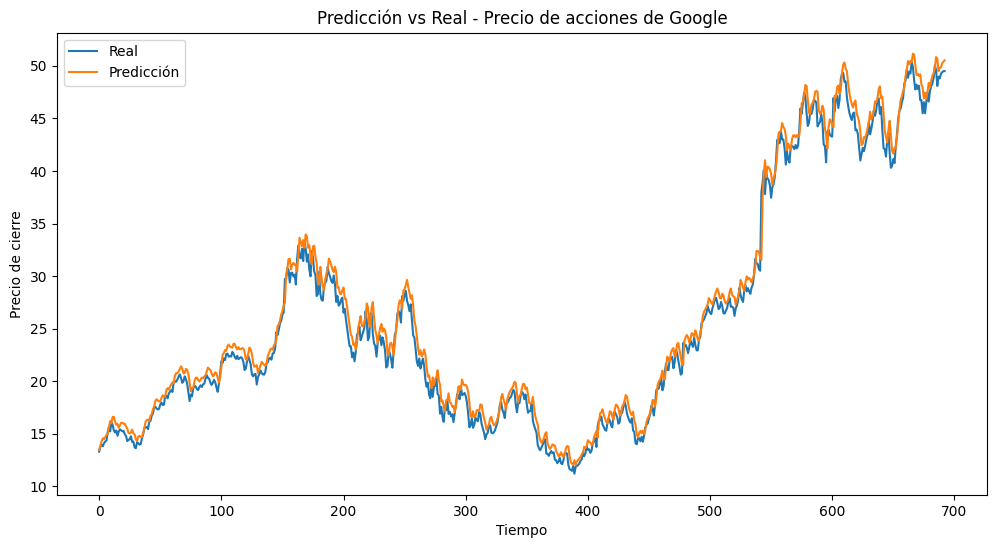

In [17]:
# 2. Predicción de series temporales con LSTM

# Importar librerías
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf

# Cargar datos
data = yf.download('NVDA', start='2010-01-01', end='2023-12-31')
data = data[['Close']]

# Visualizar datos
plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title('Precio de cierre de acciones de Google')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.show()

# Preprocesamiento
dataset = data.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Crear secuencias
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60  # Puedes modificar este valor como ejercicio
X, y = create_sequences(dataset_scaled, sequence_length)

# Dividir en entrenamiento y prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Construir modelo LSTM
model = Sequential()
model.add(Bidirectional(LSTM(512, return_sequences=True, input_shape=(sequence_length, 1))))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(256)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Visualizar resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Real')
plt.plot(predictions, label='Predicción')
plt.title('Predicción vs Real - Precio de acciones de Google')
plt.xlabel('Tiempo')
plt.ylabel('Precio de cierre')
plt.legend()
plt.show()


# Cambiar el tipo de datos

## 3. Análisis de sentimiento en reseñas de películas con Simple RNN

**Descripción:**

Clasificaremos reseñas de películas como positivas o negativas utilizando una RNN simple.

**Instrucciones:**

1. Importar las librerías necesarias.
2. Cargar y preprocesar los datos de IMDB desde TensorFlow Datasets.
3. Construir y entrenar el modelo Simple RNN.
4. Evaluar el modelo y visualizar la precisión.

**Ejercicio:**

Prueba a cambiar el tamaño del embedding o el número de unidades en la capa RNN y observa cómo afecta al rendimiento.

In [ ]:
# 3. Análisis de sentimiento en reseñas de películas con Simple RNN

# Importar librerías
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Cargar datos
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

# Preprocesamiento
BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Construir modelo RNN simple
model = Sequential([
    encoder,
    Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    SimpleRNN(64),  # Puedes modificar el número de unidades como ejercicio
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, epochs=3, validation_data=test_dataset)

# Evaluación
test_loss, test_acc = model.evaluate(test_dataset)
print('Precisión en el conjunto de prueba:', test_acc)

# Visualizar precisión
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo de Análisis de Sentimiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.8IQENS_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.8IQENS_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.8IQENS_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5035 - loss: 0.6951

## 4. Predicción de temperatura con GRU

**Descripción:**

Usaremos datos meteorológicos de Jena para predecir la temperatura utilizando una GRU.

**Instrucciones:**

1. Importar las librerías necesarias.
2. Cargar y preprocesar los datos desde TensorFlow Datasets.
3. Crear secuencias para entrenamiento.
4. Construir y entrenar el modelo GRU.
5. Realizar predicciones y visualizar los resultados.

**Ejercicio:**

Intenta utilizar una LSTM en lugar de una GRU y compara los resultados.

In [ ]:
# 4. Predicción de temperatura con GRU

# Importar librerías
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
zip_path = tf.keras.utils.get_file(origin='https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip',
                                   fname='jena_climate_2009_2016.csv.zip',
                                   extract=True)
csv_path, _ = zip_path.rsplit('.', 1)
data = np.loadtxt(csv_path, delimiter=',', skiprows=1)

# Preprocesamiento
mean = data[:200000].mean(axis=0)
data -= mean
std = data[:200000].std(axis=0)
data /= std

# Crear generador de datos
def generator(data, lookback, delay, min_index, max_index, shuffle=False, batch_size=128, step=6):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while True:
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)
        samples = np.zeros((len(rows),
                            lookback // step,
                            data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices]
            targets[j] = data[rows[j] + delay][1]  # Columna de temperatura
        yield samples, targets

lookback = 1440
step = 6
delay = 144
batch_size = 128

train_gen = generator(data,
                      lookback=lookback,
                      delay=delay,
                      min_index=0,
                      max_index=200000,
                      shuffle=True,
                      step=step,
                      batch_size=batch_size)
val_gen = generator(data,
                    lookback=lookback,
                    delay=delay,
                    min_index=200001,
                    max_index=300000,
                    step=step,
                    batch_size=batch_size)

val_steps = (300000 - 200001 - lookback) // batch_size

# Construir modelo GRU
model = Sequential()
model.add(GRU(32, input_shape=(None, data.shape[-1])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mae')
history = model.fit(train_gen,
                    steps_per_epoch=500,
                    epochs=5,
                    validation_data=val_gen,
                    validation_steps=val_steps)

# Visualizar pérdida
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()
plt.plot(epochs, loss, 'bo', label='Pérdida de entrenamiento')
plt.plot(epochs, val_loss, 'b', label='Pérdida de validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.legend()
plt.show()


## 5. Detección de fraudes en transacciones con LSTM

**Descripción:**

Implementaremos una LSTM para detectar transacciones fraudulentas utilizando el conjunto de datos de Kaggle de transacciones con tarjetas de crédito.

**Instrucciones:**

1. Importar las librerías necesarias.
2. Cargar y preprocesar los datos desde Kaggle (usando Kaggle API).
3. Equilibrar el conjunto de datos.
4. Preparar los datos para LSTM.
5. Construir y entrenar el modelo LSTM.
6. Evaluar el modelo.

**Ejercicio:**

Experimenta cambiando el número de capas o neuronas en la LSTM y observa cómo afecta al rendimiento.

In [ ]:
# 5. Detección de fraudes en transacciones con LSTM

# Importar librerías
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Descargar datos de Kaggle
!pip install kaggle
import os
os.environ['KAGGLE_USERNAME'] = 'TU_USUARIO'
os.environ['KAGGLE_KEY'] = 'TU_CLAVE'

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

# Cargar datos
data = pd.read_csv('creditcard.csv')

# Preprocesamiento
data['NormalizedAmount'] = StandardScaler().fit_transform(data['Amount'].values.reshape(-1, 1))
data = data.drop(['Time', 'Amount'], axis=1)

# Equilibrar datos
fraud = data[data['Class'] == 1]
non_fraud = data[data['Class'] == 0].sample(len(fraud))
data_balanced = pd.concat([fraud, non_fraud])

# Preparar datos para LSTM
X = data_balanced.drop('Class', axis=1).values
y = data_balanced['Class'].values

X = X.reshape(X.shape[0], 1, X.shape[1])

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Construir modelo LSTM
model = Sequential()
model.add(LSTM(32, input_shape=(X.shape[1], X.shape[2])))  # Puedes modificar este valor como ejercicio
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Evaluación
y_pred = model.predict(X_test) > 0.5
print(classification_report(y_test, y_pred))


## 6. Pronóstico de demanda energética con RNN

**Descripción:**

Desarrollaremos una RNN para predecir la demanda energética utilizando el conjunto de datos de consumo eléctrico.

**Instrucciones:**

1. Importar las librerías necesarias.
2. Cargar y preprocesar los datos desde UCI Machine Learning Repository.
3. Crear secuencias para entrenamiento.
4. Construir y entrenar el modelo RNN.
5. Realizar predicciones y visualizar los resultados.

**Ejercicio:**

Prueba a utilizar una GRU en lugar de una RNN simple y compara los resultados.

In [ ]:
# 6. Pronóstico de demanda energética con RNN

# Importar librerías
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Cargar datos
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv'
data = pd.read_csv(url)
data = data[['Appliances']]

# Preprocesamiento
dataset = data.values.astype('float32')
scaler = MinMaxScaler()
dataset_scaled = scaler.fit_transform(dataset)

# Crear secuencias
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 10
X, y = create_sequences(dataset_scaled, sequence_length)

# Dividir en entrenamiento y prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Construir modelo RNN
model = Sequential()
model.add(SimpleRNN(32, input_shape=(sequence_length, 1)))  # Puedes cambiar a GRU como ejercicio
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=5, batch_size=16, validation_data=(X_test, y_test))

# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Visualizar resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Real')
plt.plot(predictions, label='Predicción')
plt.title('Pronóstico de Demanda Energética')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de Energía')
plt.legend()
plt.show()
